# *ASSIGNMENT-1: Find the communities*

In [7]:
import networkx as nx
import pandas as pd
from pathlib import Path
import community as community_louvain
import time
from itertools import combinations
import igraph as ig
import leidenalg
from networkx.algorithms.community import girvan_newman
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
import matplotlib.pyplot as plt

In [8]:
BASE_DIR = Path().resolve().parent.parent
DATASET_PATH = BASE_DIR / "data" / "anime_filtered.csv"
df = pd.read_csv(DATASET_PATH)

In [9]:
def build_graph(filtered):
    G = nx.Graph()
    for _, row in filtered.iterrows():
        G.add_node(row["mal_id"], title=row["title"])
    for (_, a), (_, b) in combinations(filtered.iterrows(), 2):
        genres_a = set(str(a["genres"]).split("|"))
        genres_b = set(str(b["genres"]).split("|"))
        if len(genres_a & genres_b) >= 2:
            G.add_edge(a["mal_id"], b["mal_id"])
    return G

In [10]:
G = build_graph(filtered=df)
print(G.number_of_nodes())
print(G.number_of_edges())

3579
780393


In [11]:
print("Running Louvain...")

start = time.time()
louvain_partition = community_louvain.best_partition(G)
louvain_runtime = time.time() - start
print("Runtime:", louvain_runtime)

num_communities = len(set(louvain_partition.values()))
print("Number of communities:", num_communities)

sizes = {}
for node, comm in louvain_partition.items():
    sizes[comm] = sizes.get(comm, 0) + 1

print("\nLargest communities:")
for community, size in sorted(sizes.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(community, size)

Running Louvain...
Runtime: 9.339388847351074
Number of communities: 735

Largest communities:
15 967
1 852
13 657
7 310
340 21
3 13
76 11
307 8
32 7
310 4


In [12]:
nodes = list(G.nodes())
mapping = {node: i for i, node in enumerate(nodes)}

edges = [(mapping[u], mapping[v]) for u, v in G.edges()]
ig_graph = ig.Graph(edges=edges, n=len(nodes))

In [13]:
print("--- iGraph conversion ---")
print("Nodes (iGraph):", ig_graph.vcount())
print("Edges (iGraph):", ig_graph.ecount())

print("Sample mapping:", list(mapping.items())[:5])
print("Sample edges (mapped):", edges[:5])

--- iGraph conversion ---
Nodes (iGraph): 3579
Edges (iGraph): 780393
Sample mapping: [(1, 0), (5, 1), (6, 2), (7, 3), (15, 4)]
Sample edges (mapped): [(0, 1), (0, 2), (0, 12), (0, 14), (0, 16)]


In [14]:
print("Running Leiden...")
start = time.time()
leiden_partition = leidenalg.find_partition(ig_graph, leidenalg.ModularityVertexPartition)
leiden_runtime = time.time() - start
print("Runtime:", leiden_runtime)

Running Leiden...
Runtime: 0.6887853145599365


In [15]:
communities = leiden_partition.membership
num_communities = len(set(communities))
print("Communities:", num_communities)

sizes = {}
for node, comm in zip(nodes, communities):
    sizes[comm] = sizes.get(comm, 0) + 1

print("\nLargest communities:")
for community, size in sorted(sizes.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(community, size)

Communities: 733

Largest communities:
0 1004
1 984
2 672
3 147
4 20
5 11
6 8
7 4
8 3
9 2


In [16]:
nodes_list = list(G.nodes())
louvain_labels = [louvain_partition[n] for n in nodes_list]
leiden_labels = leiden_partition.membership

In [17]:
def compare(name1, labels1, name2, labels2):
    nmi = normalized_mutual_info_score(labels1, labels2)
    ari = adjusted_rand_score(labels1, labels2)
    
    print(f"{name1} vs {name2}")
    print("NMI:", nmi)
    print("ARI:", ari)

In [18]:
compare("Louvain", louvain_labels, "Leiden", leiden_labels)

Louvain vs Leiden
NMI: 0.889649267264925
ARI: 0.7492234258369413


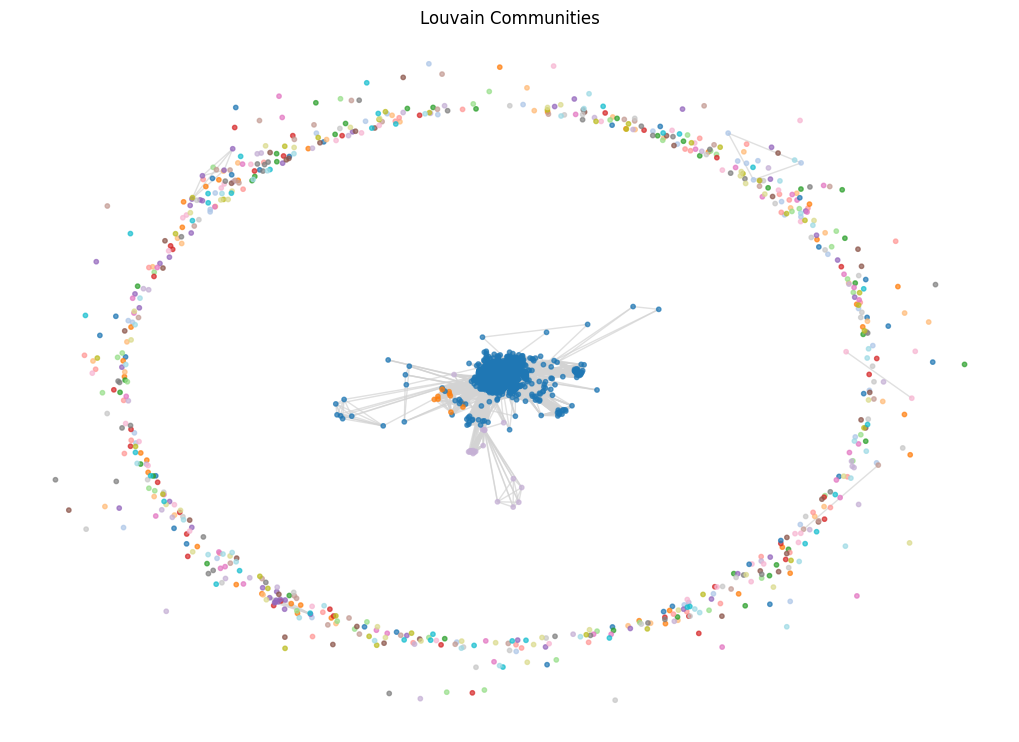

In [19]:
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=10, node_color=list(louvain_partition.values()),
    cmap=plt.cm.tab20, edge_color="lightgray", alpha=0.7)
plt.title("Louvain Communities")
plt.show()

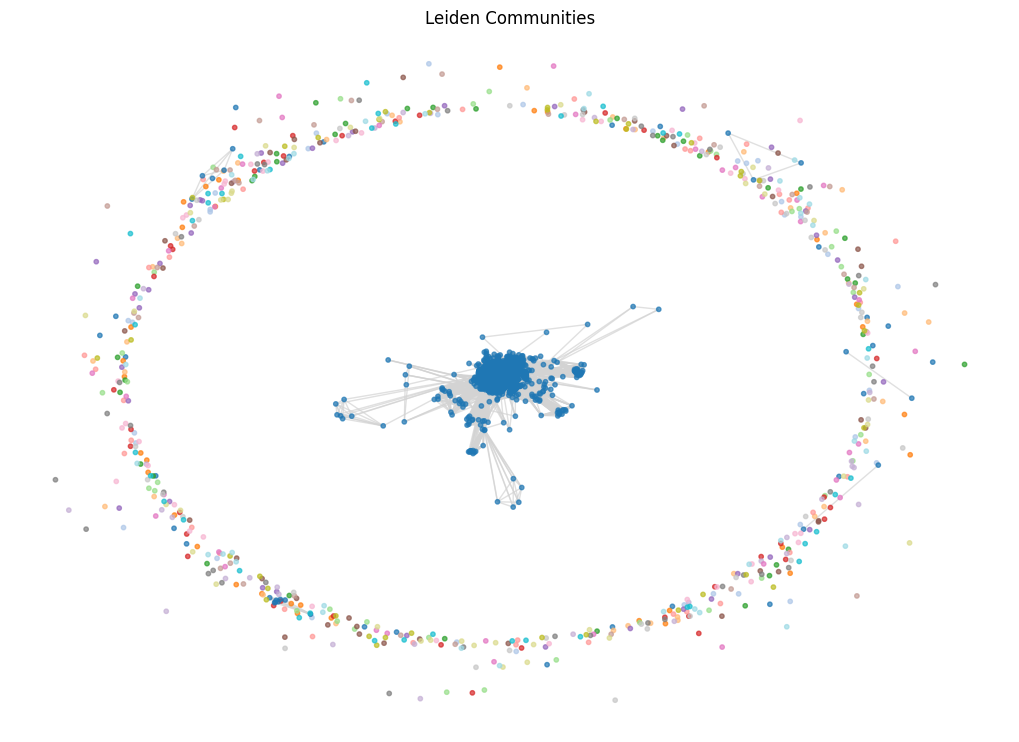

In [20]:
leiden_colors = dict(zip(nodes, leiden_partition.membership))
plt.figure(figsize=(10, 7))
nx.draw(G, pos, node_size=10, node_color=[leiden_colors[n] for n in G.nodes()],
    cmap=plt.cm.tab20, edge_color="lightgray", alpha=0.7)
plt.title("Leiden Communities")
plt.show()

In [21]:
small_G = G.copy()
small_G = small_G.subgraph(list(small_G.nodes())[:200])

start = time.time()
gn = girvan_newman(small_G)
gn_partition = next(gn)
gn_runtime = time.time() - start

print("GN runtime:", gn_runtime)
print("Communities:", len(gn_partition))

GN runtime: 0.26684045791625977
Communities: 27


In [22]:
summary = pd.DataFrame({
    "Algorithm": ["Louvain", "Leiden", "Girvan-Newman (subgraph)"],
    "Communities": [
        len(set(louvain_partition.values())),
        len(set(leiden_partition.membership)),
        len(gn_partition)
    ],
    "Runtime (s)": [
        louvain_runtime,
        leiden_runtime,
        gn_runtime
    ]
})
summary

,Algorithm,Communities,Runtime (s)
0,Louvain,735,9.339389
1,Leiden,733,0.688785
2,Girvan-Newman (subgraph),27,0.266840
